In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# ── Grafik stili ayarları ──────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('husl')

# ── Numpy yazdırma hassasiyeti ─────────────────────────────────────────────
np.set_printoptions(precision=4, suppress=True)

print('✅ Tüm kütüphaneler başarıyla yüklendi.')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅ Tüm kütüphaneler başarıyla yüklendi.
   NumPy  : 2.0.2
   Pandas : 2.2.2


In [3]:

df = pd.read_csv('tvmarketing.csv')

print('=' * 60)
print('📊 TV MARKETING VERİSİ')
print('=' * 60)
print(f'  Satır sayısı  : {df.shape[0]:,}')
print(f'  Sütun sayısı  : {df.shape[1]}')
print(f'  Sütunlar      : {list(df.columns)}')
print()

print('İlk 5 satır:')
print(df[['TV', 'Sales']].head())

📊 TV MARKETING VERİSİ
  Satır sayısı  : 200
  Sütun sayısı  : 2
  Sütunlar      : ['TV', 'Sales']

İlk 5 satır:
      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9


In [4]:

null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Eksik Sayı': null_counts,
    'Eksik Yüzde (%)': null_pct,
    'Veri Tipi': df.dtypes
}).sort_values('Eksik Sayı', ascending=False)


print('📋 Eksik Değer Raporu:')
print(null_df[null_df['Eksik Sayı'] > 0].to_string())
print()
print(f'⚠️  Toplam {(null_counts > 0).sum()} sütunda eksik veri mevcut.')

📋 Eksik Değer Raporu:
Empty DataFrame
Columns: [Eksik Sayı, Eksik Yüzde (%), Veri Tipi]
Index: []

⚠️  Toplam 0 sütunda eksik veri mevcut.


In [5]:

stats = df[['TV', 'Sales']].describe().round(3)

print('📈 İstatistiksel Özet:')
print(stats)
print()
print('💡 İçgörüler:')
print(f'  • Ortalama TV harcaması : {stats.loc["mean", "TV"]:.2f}')
print(f'  • Ortalama Sales        : {stats.loc["mean", "Sales"]:.2f}')
print(f'  • TV harcaması aralığı  : {stats.loc["min", "TV"]:.2f} → {stats.loc["max", "TV"]:.2f}')
print(f'  • Sales aralığı          : {stats.loc["min", "Sales"]:.2f} → {stats.loc["max", "Sales"]:.2f}')
print(f'  • TV std                 : {stats.loc["std", "TV"]:.2f}')
print(f'  • Sales std              : {stats.loc["std", "Sales"]:.2f}')

📈 İstatistiksel Özet:
            TV    Sales
count  200.000  200.000
mean   147.042   14.022
std     85.854    5.217
min      0.700    1.600
25%     74.375   10.375
50%    149.750   12.900
75%    218.825   17.400
max    296.400   27.000

💡 İçgörüler:
  • Ortalama TV harcaması : 147.04
  • Ortalama Sales        : 14.02
  • TV harcaması aralığı  : 0.70 → 296.40
  • Sales aralığı          : 1.60 → 27.00
  • TV std                 : 85.85
  • Sales std              : 5.22


In [6]:

cols = ['TV', 'Sales']
data = df[cols].copy()

for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

n_before = len(data)
data = data.dropna()
n_after  = len(data)

print(f'🧹 Temizleme Raporu:')
print(f'  Önceki satır sayısı : {n_before:,}')
print(f'  Sonraki satır sayısı: {n_after:,}')
print(f'  Silinen satır sayısı: {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.2f}%)')
print()


print('🔍 IQR Aykırı Değer Analizi:')
for col in ['TV', 'Sales']:
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f'  {col:10s} | IQR={IQR:.2f} | [{lower:.2f}, {upper:.2f}] | {len(outliers):,} aykırı değer ({len(outliers)/len(data)*100:.2f}%)')

print()
print('✅ Veri temizleme tamamlandı.')
data.head()

🧹 Temizleme Raporu:
  Önceki satır sayısı : 200
  Sonraki satır sayısı: 200
  Silinen satır sayısı: 0 (0.00%)

🔍 IQR Aykırı Değer Analizi:
  TV         | IQR=144.45 | [-142.30, 435.50] | 0 aykırı değer (0.00%)
  Sales      | IQR=7.02 | [-0.16, 27.94] | 0 aykırı değer (0.00%)

✅ Veri temizleme tamamlandı.


,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


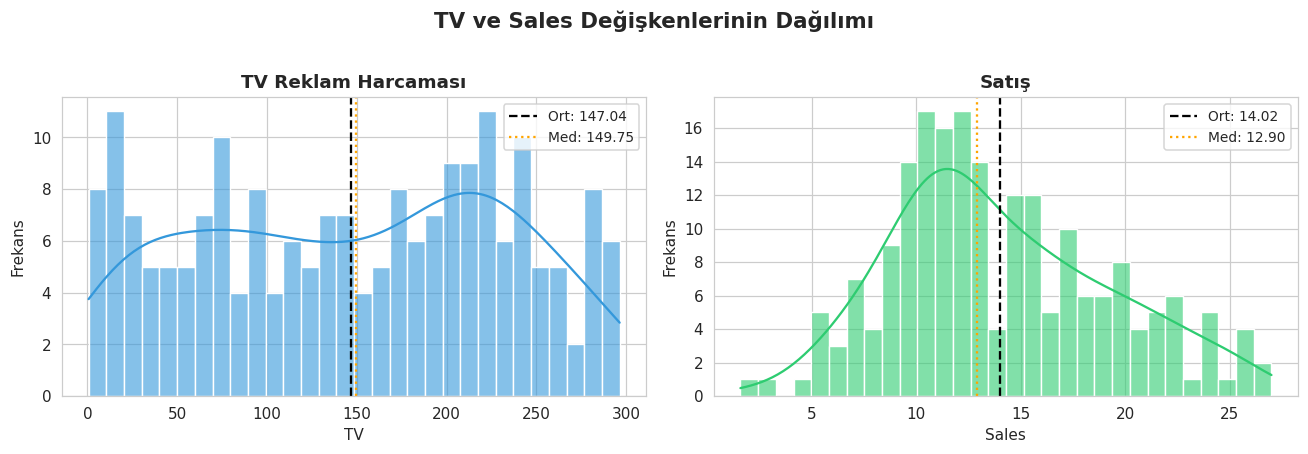

💡 Yorum:
  • TV ve Sales değişkenlerinin dağılımları histogram ve KDE grafikleri ile incelendi.
  • Ortalama ve medyan değerleri karşılaştırılarak dağılımın simetrisi değerlendirilebilir.
  • TV reklam harcaması ile Sales arasındaki ilişki polynomial regression için ayrıca incelenecektir.


In [7]:
#Dağılım Grafikleri
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('TV ve Sales Değişkenlerinin Dağılımı', fontsize=14, fontweight='bold', y=1.02)

vars_info = [
    ('TV', '#3498db', 'TV Reklam Harcaması'),
    ('Sales', '#2ecc71', 'Satış'),
]

for ax, (col, color, label) in zip(axes, vars_info):

    sns.histplot(data[col], bins=30, kde=True, color=color, alpha=0.6, ax=ax)


    mean_val   = data[col].mean()
    median_val = data[col].median()
    ax.axvline(mean_val,   color='black',  linestyle='--', linewidth=1.5, label=f'Ort: {mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle=':',  linewidth=1.5, label=f'Med: {median_val:.2f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekans')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('💡 Yorum:')
print('  • TV ve Sales değişkenlerinin dağılımları histogram ve KDE grafikleri ile incelendi.')
print('  • Ortalama ve medyan değerleri karşılaştırılarak dağılımın simetrisi değerlendirilebilir.')
print('  • TV reklam harcaması ile Sales arasındaki ilişki polynomial regression için ayrıca incelenecektir.')

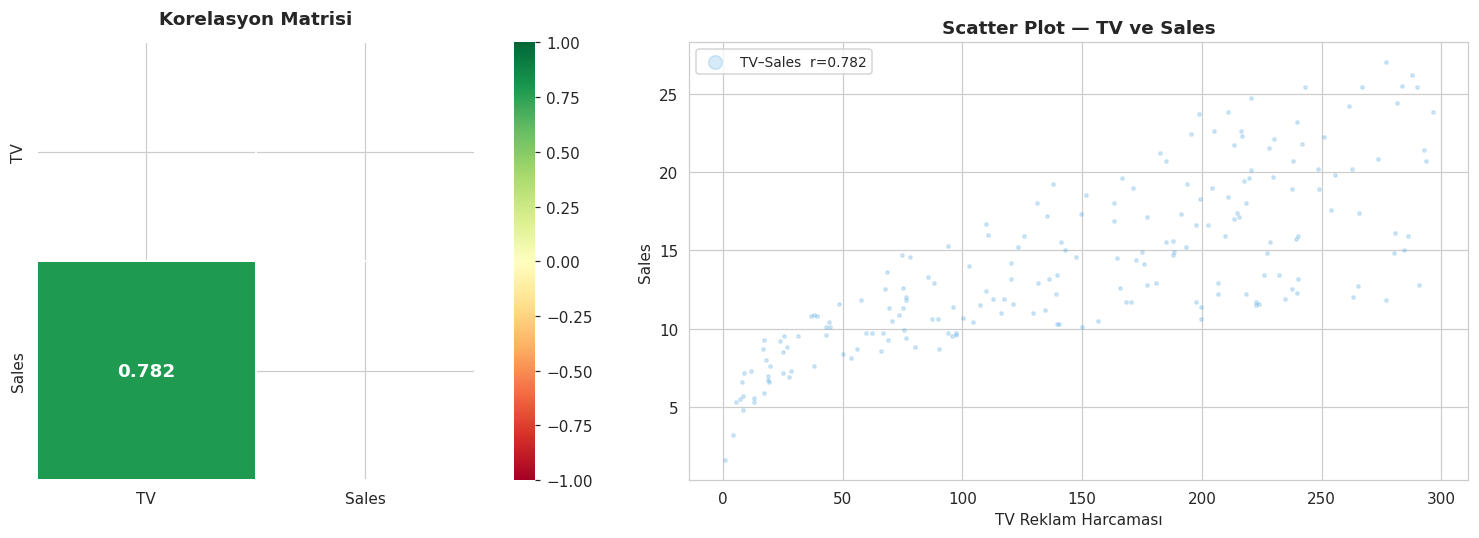

💡 Yorum:
  • TV–Sales korelasyonu: r = 0.782
  • TV reklam harcaması ile Sales arasında güçlü pozitif ilişki bulunmaktadır.
  • Scatter plot, ilişkinin doğrusal mı yoksa eğrisel mi olduğunu incelememizi sağlar.
  • Bu nedenle Polynomial Regression öncesinde TV–Sales ilişkisini görsel olarak incelemek önemlidir.


In [8]:
#Korelasyon ısı haritası
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Sol--> Korelasyon matrisi
corr_matrix = data[['TV', 'Sales']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Üst üçgeni gizle

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=1, ax=axes[0],
    annot_kws={'size': 12, 'weight': 'bold'}
)

axes[0].set_title('Korelasyon Matrisi', fontweight='bold', pad=12)

#Sağ--> Scatter plot
sample = data.sample(min(3000, len(data)), random_state=42)

r_tv_sales = corr_matrix.loc['TV', 'Sales']

axes[1].scatter(
    sample['TV'],
    sample['Sales'],
    alpha=0.2,
    s=5,
    color='#3498db',
    label=f'TV–Sales  r={r_tv_sales:.3f}'
)

axes[1].set_xlabel('TV Reklam Harcaması')
axes[1].set_ylabel('Sales')
axes[1].set_title('Scatter Plot — TV ve Sales', fontweight='bold')
axes[1].legend(fontsize=9, markerscale=4)

plt.tight_layout()
plt.show()

print('💡 Yorum:')
print(f'  • TV–Sales korelasyonu: r = {r_tv_sales:.3f}')

if r_tv_sales >= 0.7:
    print('  • TV reklam harcaması ile Sales arasında güçlü pozitif ilişki bulunmaktadır.')
elif r_tv_sales >= 0.4:
    print('  • TV reklam harcaması ile Sales arasında orta düzeyde pozitif ilişki bulunmaktadır.')
elif r_tv_sales >= 0:
    print('  • TV reklam harcaması ile Sales arasında zayıf pozitif ilişki bulunmaktadır.')
else:
    print('  • TV reklam harcaması ile Sales arasında negatif ilişki bulunmaktadır.')

print('  • Scatter plot, ilişkinin doğrusal mı yoksa eğrisel mi olduğunu incelememizi sağlar.')
print('  • Bu nedenle Polynomial Regression öncesinde TV–Sales ilişkisini görsel olarak incelemek önemlidir.')

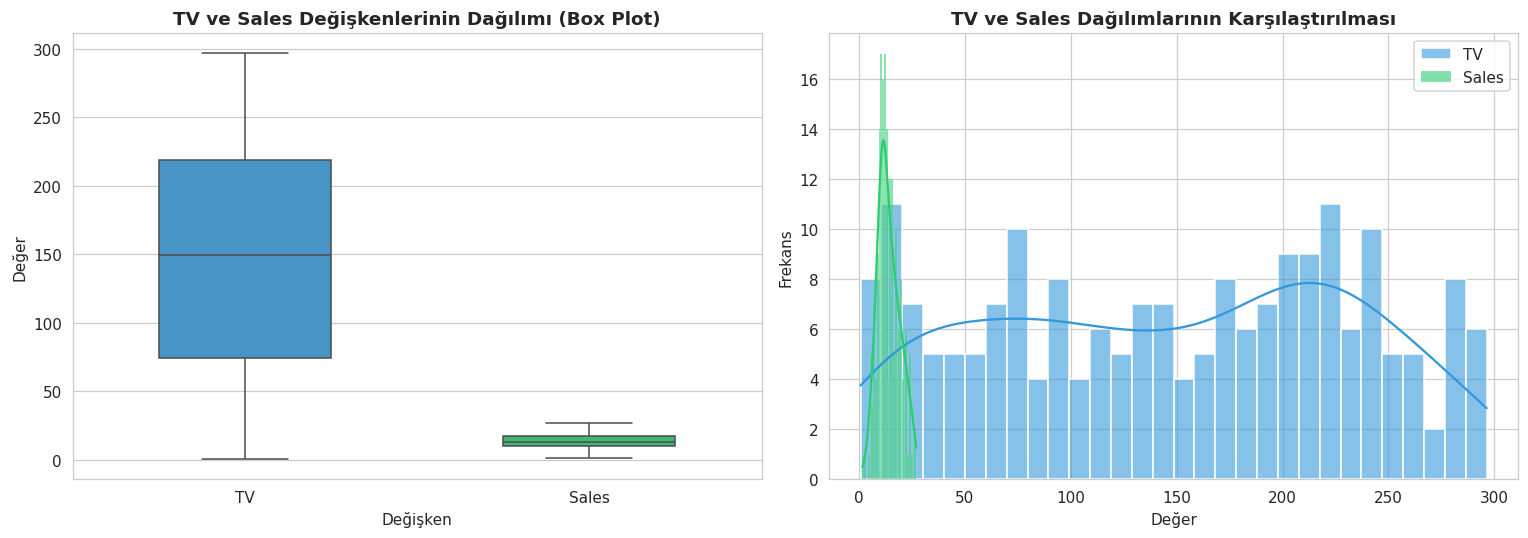

In [9]:
#Box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Sol--> TV ve Sales değişkenlerinin birlikte box plot'u
data_melted = data[['TV', 'Sales']].melt(
    var_name='Değişken',
    value_name='Değer'
)

sns.boxplot(
    x='Değişken',
    y='Değer',
    data=data_melted,
    palette=['#3498db', '#2ecc71'],
    width=0.5,
    fliersize=1.5,
    ax=axes[0]
)

axes[0].set_title(
    'TV ve Sales Değişkenlerinin Dağılımı (Box Plot)',
    fontweight='bold'
)
axes[0].set_xlabel('Değişken')
axes[0].set_ylabel('Değer')


#Sağ--> TV ve Sales dağılımlarının histogramı
sns.histplot(
    data['TV'],
    bins=30,
    kde=True,
    color='#3498db',
    alpha=0.6,
    label='TV',
    ax=axes[1]
)

sns.histplot(
    data['Sales'],
    bins=30,
    kde=True,
    color='#2ecc71',
    alpha=0.6,
    label='Sales',
    ax=axes[1]
)

axes[1].set_xlabel('Değer')
axes[1].set_ylabel('Frekans')
axes[1].set_title(
    'TV ve Sales Dağılımlarının Karşılaştırılması',
    fontweight='bold'
)
axes[1].legend()

plt.tight_layout()
plt.show()

**POLİNOMAL REGRESYON MODELİ **

In [10]:
#Özellik ve hedef değişkeni belirliyoruz
# Bağımsız değişken (X): TV
# Bağımlı değişken (y) : Sales

X = data[['TV']].values
y = data['Sales'].values

#Train-Test ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print('📊 Veri Bölme Sonuçları:')
print(f'  Toplam veri : {len(X):,} örnek')
print(f'  Eğitim seti : {len(X_train):,} örnek ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test seti   : {len(X_test):,} örnek  ({len(X_test)/len(X)*100:.0f}%)')
print()
print(f'  X_train boyutu: {X_train.shape}')
print(f'  y_train boyutu: {y_train.shape}')
print()
print('💡 Neden 2D X?')
print('  scikit-learn modelleri X i (n_samples, n_features) formatında bekler.')
print('  data[["TV"]].values → (n,1)   ✅')
print('  data["TV"].values   → (n,)    ❌ (tek özellik için çalışır ama kötü alışkanlık)')

📊 Veri Bölme Sonuçları:
  Toplam veri : 200 örnek
  Eğitim seti : 160 örnek (80%)
  Test seti   : 40 örnek  (20%)

  X_train boyutu: (160, 1)
  y_train boyutu: (160,)

💡 Neden 2D X?
  scikit-learn modelleri X i (n_samples, n_features) formatında bekler.
  data[["TV"]].values → (n,1)   ✅
  data["TV"].values   → (n,)    ❌ (tek özellik için çalışır ama kötü alışkanlık)


In [11]:
#Polinom dönüşüme bakıyoruz
print('🔍 PolynomialFeatures Dönüşümü — Somut Örnek:')
print('   Girdi TV = [[2], [3], [5]]')
print()

X_example = np.array([[2], [3], [5]])

for degree in [1, 2, 3]:
    pf = PolynomialFeatures(degree=degree, include_bias=True)
    X_transformed = pf.fit_transform(X_example)

    print(f'  Derece {degree}: {X_transformed.tolist()}')
    print(f'    Özellik isimleri: {pf.get_feature_names_out(["TV"])}')
    print()

print('💡 "include_bias=True" → Sabit terim (1.0) sütunu eklenir.')
print('   Bu, LinearRegression intercept değerine karşılık gelir.')

🔍 PolynomialFeatures Dönüşümü — Somut Örnek:
   Girdi TV = [[2], [3], [5]]

  Derece 1: [[1.0, 2.0], [1.0, 3.0], [1.0, 5.0]]
    Özellik isimleri: ['1' 'TV']

  Derece 2: [[1.0, 2.0, 4.0], [1.0, 3.0, 9.0], [1.0, 5.0, 25.0]]
    Özellik isimleri: ['1' 'TV' 'TV^2']

  Derece 3: [[1.0, 2.0, 4.0, 8.0], [1.0, 3.0, 9.0, 27.0], [1.0, 5.0, 25.0, 125.0]]
    Özellik isimleri: ['1' 'TV' 'TV^2' 'TV^3']

💡 "include_bias=True" → Sabit terim (1.0) sütunu eklenir.
   Bu, LinearRegression intercept değerine karşılık gelir.


In [12]:
#Model eğitimi döngüsü
# X = TV, y = Sales
degrees = [1, 2, 3, 4, 5, 7, 10]
models  = {}
results = []

for degree in degrees:
    #Pipeline oluşturuyoruz: PolynomialFeatures → LinearRegression
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=True),
        LinearRegression()
    )

    #Modeli SADECE eğitim verisiyle eğitiyoruz
    model.fit(X_train, y_train)
    models[degree] = model


    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)


    train_r2   = r2_score(y_train, y_train_pred)
    test_r2    = r2_score(y_test,  y_test_pred)
    train_mse  = mean_squared_error(y_train, y_train_pred)
    test_mse   = mean_squared_error(y_test,  y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse  = np.sqrt(test_mse)

    results.append({
        'Derece'    : degree,
        'Train R²'  : round(train_r2,   4),
        'Test R²'   : round(test_r2,    4),
        'Δ R²'      : round(train_r2 - test_r2, 4),
        'Train RMSE': round(train_rmse, 4),
        'Test RMSE' : round(test_rmse,  4),
        'Train MSE' : round(train_mse,  4),
        'Test MSE'  : round(test_mse,   4),
    })

    #rapor
    flag = '⚠️ Overfitting riski!' if (train_r2 - test_r2) > 0.01 else '✅'
    print(
        f'Derece {degree:2d} | '
        f'Train R²={train_r2:.4f} | '
        f'Test R²={test_r2:.4f} | '
        f'ΔR²={train_r2-test_r2:.4f} {flag}'
    )

results_df = pd.DataFrame(results)

print()
print('─' * 65)
print('📋 Tam Sonuç Tablosu:')
print(results_df.to_string(index=False))

Derece  1 | Train R²=0.5912 | Test R²=0.6767 | ΔR²=-0.0855 ✅
Derece  2 | Train R²=0.5988 | Test R²=0.6825 | ΔR²=-0.0837 ✅
Derece  3 | Train R²=0.6056 | Test R²=0.6695 | ΔR²=-0.0640 ✅
Derece  4 | Train R²=0.6058 | Test R²=0.6717 | ΔR²=-0.0659 ✅
Derece  5 | Train R²=0.6119 | Test R²=0.6767 | ΔR²=-0.0648 ✅
Derece  7 | Train R²=0.5935 | Test R²=0.6639 | ΔR²=-0.0704 ✅
Derece 10 | Train R²=0.5648 | Test R²=0.6239 | ΔR²=-0.0591 ✅

─────────────────────────────────────────────────────────────────
📋 Tam Sonuç Tablosu:
 Derece  Train R²  Test R²    Δ R²  Train RMSE  Test RMSE  Train MSE  Test MSE
      1    0.5912   0.6767 -0.0855      3.2563     3.1945    10.6036   10.2047
      2    0.5988   0.6825 -0.0837      3.2258     3.1655    10.4056   10.0201
      3    0.6056   0.6695 -0.0640      3.1984     3.2296    10.2299   10.4302
      4    0.6058   0.6717 -0.0659      3.1975     3.2188    10.2241   10.3609
      5    0.6119   0.6767 -0.0648      3.1727     3.1945    10.0658   10.2050
      7    

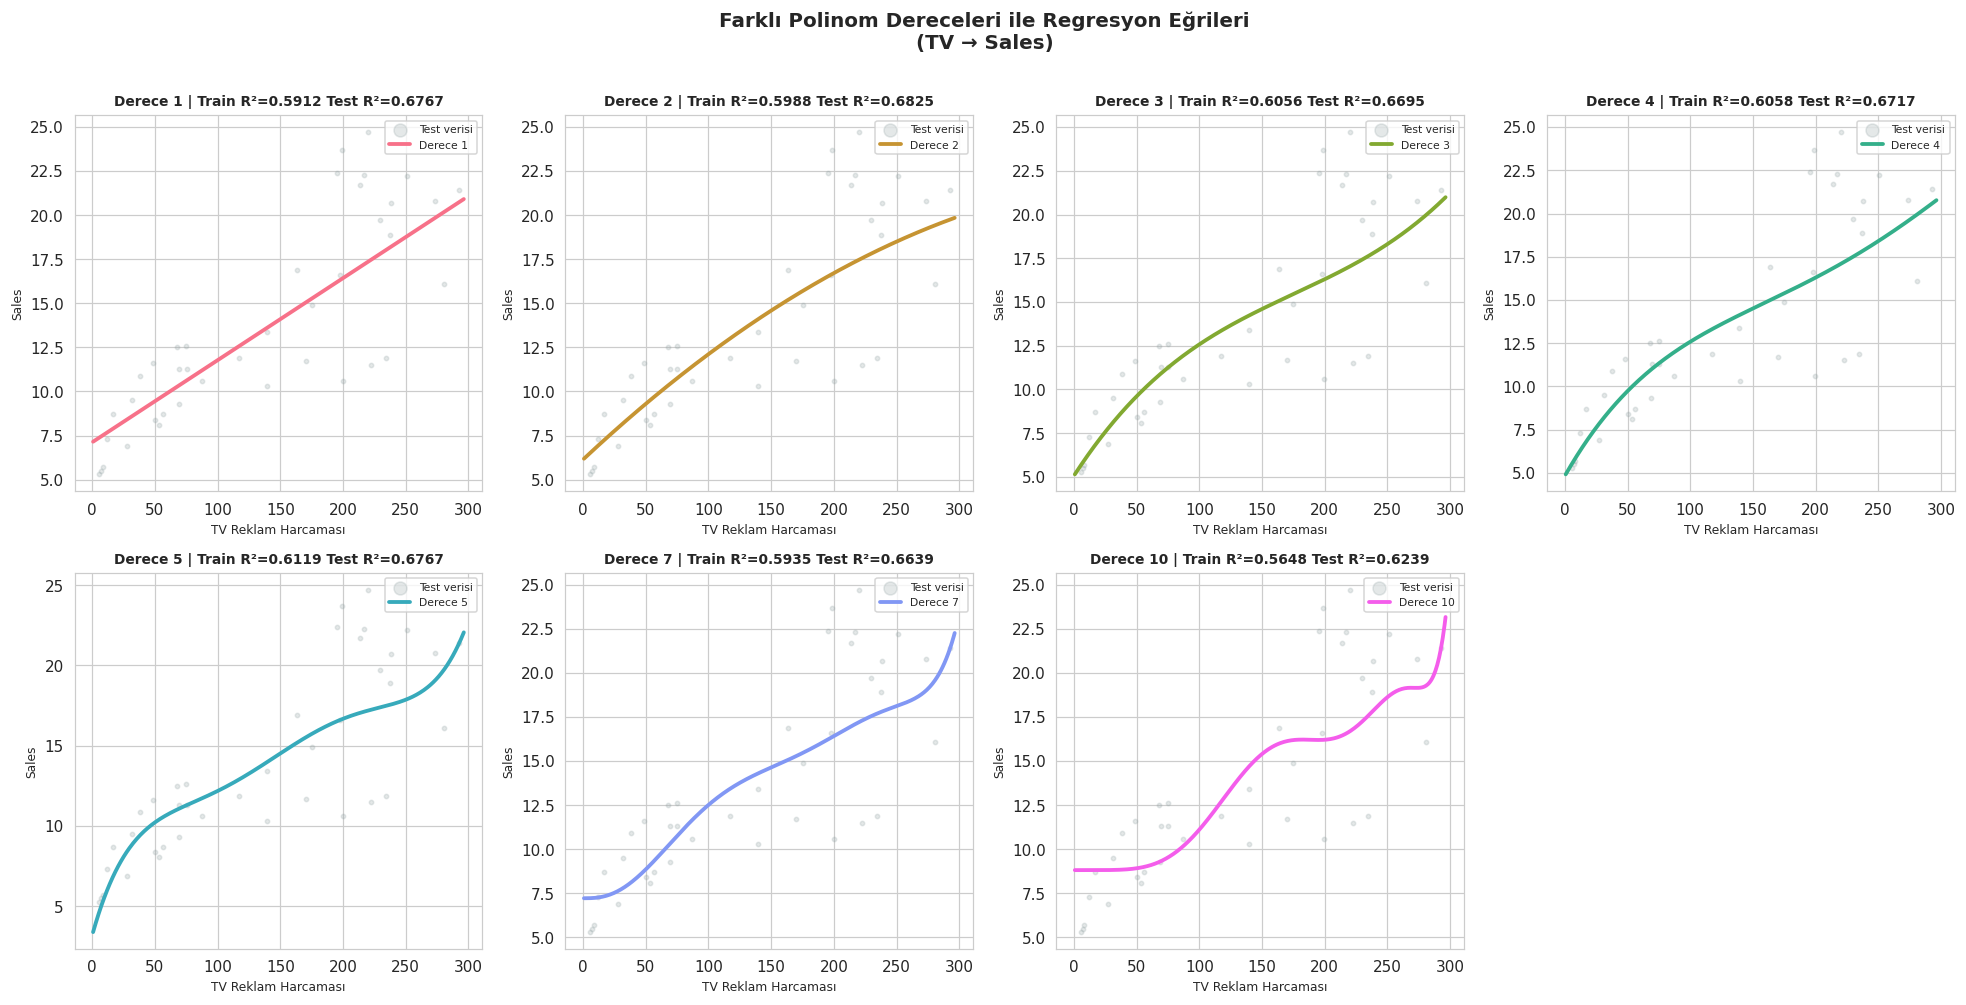

💡 Yorum:
  • Derece 1: Doğrusal bir regresyon çizgisi oluşturur.
  • Derece 2-3: TV ve Sales arasındaki olası eğrisel ilişkiyi yakalar.
  • Daha yüksek dereceler: Veriye daha fazla uyum sağlayabilir.
  • Çok yüksek derecelerde eğrinin aşırı bükülmesi overfitting göstergesi olabilir.


In [13]:
#Regresyon eğrileri
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

#sıralı X ekseni
X_line = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)

palette = sns.color_palette('husl', len(degrees))

sample_size = min(1500, len(X_test))
sample_idx = np.random.choice(len(X_test), sample_size, replace=False)


for i, degree in enumerate(degrees):
    ax = axes[i]
    model = models[degree]
    row = results_df[results_df['Derece'] == degree].iloc[0]

    ax.scatter(
        X_test[sample_idx],
        y_test[sample_idx],
        alpha=0.25,
        s=8,
        color='#95a5a6',
        label='Test verisi'
    )

    ax.plot(
        X_line,
        model.predict(X_line),
        color=palette[i],
        linewidth=2.5,
        label=f'Derece {degree}'
    )


    ax.set_title(
        f'Derece {degree} | '
        f'Train R²={row["Train R²"]:.4f} '
        f'Test R²={row["Test R²"]:.4f}',
        fontsize=9,
        fontweight='bold'
    )

    ax.set_xlabel('TV Reklam Harcaması', fontsize=8)
    ax.set_ylabel('Sales', fontsize=8)
    ax.legend(fontsize=7, markerscale=3)

if len(degrees) < len(axes):
    for j in range(len(degrees), len(axes)):
        axes[j].set_visible(False)

fig.suptitle(
    'Farklı Polinom Dereceleri ile Regresyon Eğrileri\n'
    '(TV → Sales)',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

print('💡 Yorum:')
print('  • Derece 1: Doğrusal bir regresyon çizgisi oluşturur.')
print('  • Derece 2-3: TV ve Sales arasındaki olası eğrisel ilişkiyi yakalar.')
print('  • Daha yüksek dereceler: Veriye daha fazla uyum sağlayabilir.')
print('  • Çok yüksek derecelerde eğrinin aşırı bükülmesi overfitting göstergesi olabilir.')

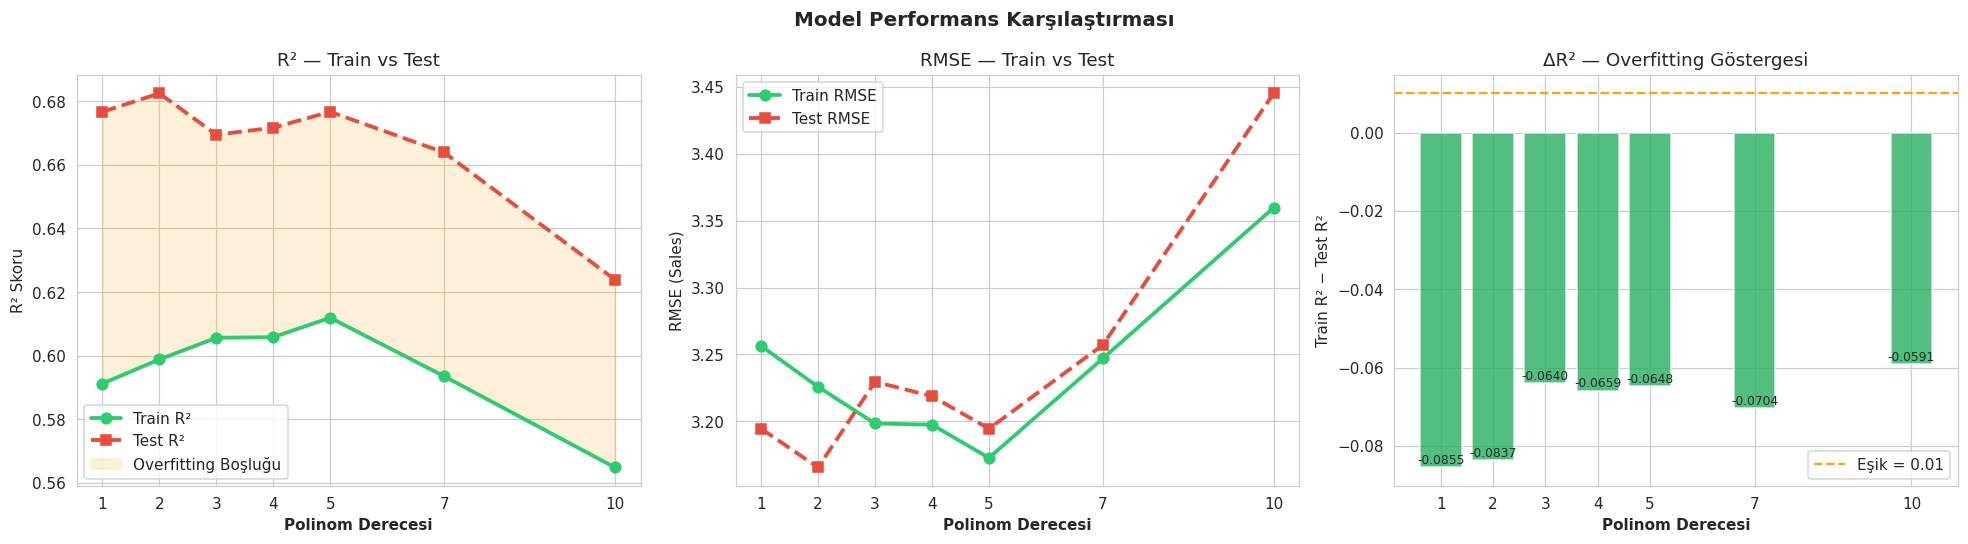

🏆 En iyi model: Derece 2
   Test R²   = 0.6825
   Test RMSE = 3.1655


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performans Karşılaştırması', fontsize=13, fontweight='bold')

x_ticks = results_df['Derece'].tolist()

#Karşılaştırıyoruz
axes[0].plot(
    results_df['Derece'],
    results_df['Train R²'],
    'o-',
    color='#2ecc71',
    linewidth=2.5,
    markersize=7,
    label='Train R²'
)

axes[0].plot(
    results_df['Derece'],
    results_df['Test R²'],
    's--',
    color='#e74c3c',
    linewidth=2.5,
    markersize=7,
    label='Test R²'
)

axes[0].fill_between(
    results_df['Derece'],
    results_df['Train R²'],
    results_df['Test R²'],
    alpha=0.15,
    color='orange',
    label='Overfitting Boşluğu'
)

axes[0].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[0].set_ylabel('R² Skoru')
axes[0].set_title('R² — Train vs Test')
axes[0].legend()
axes[0].set_xticks(x_ticks)


axes[1].plot(
    results_df['Derece'],
    results_df['Train RMSE'],
    'o-',
    color='#2ecc71',
    linewidth=2.5,
    markersize=7,
    label='Train RMSE'
)

axes[1].plot(
    results_df['Derece'],
    results_df['Test RMSE'],
    's--',
    color='#e74c3c',
    linewidth=2.5,
    markersize=7,
    label='Test RMSE'
)

axes[1].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[1].set_ylabel('RMSE (Sales)')
axes[1].set_title('RMSE — Train vs Test')
axes[1].legend()
axes[1].set_xticks(x_ticks)

colors_bar = [
    '#27ae60' if v < 0.01 else '#e74c3c'
    for v in results_df['Δ R²']
]

bars = axes[2].bar(
    results_df['Derece'],
    results_df['Δ R²'],
    color=colors_bar,
    alpha=0.8
)

axes[2].axhline(
    y=0.01,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label='Eşik = 0.01'
)

axes[2].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[2].set_ylabel('Train R² − Test R²')
axes[2].set_title('ΔR² — Overfitting Göstergesi')
axes[2].legend()
axes[2].set_xticks(x_ticks)

for bar, val in zip(bars, results_df['Δ R²']):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.0002,
        f'{val:.4f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()


#En iyi modeli seçiyoruz
best_row = results_df.loc[results_df['Test R²'].idxmax()]

print(f'🏆 En iyi model: Derece {int(best_row["Derece"])}')
print(f'   Test R²   = {best_row["Test R²"]:.4f}')
print(f'   Test RMSE = {best_row["Test RMSE"]:.4f}')

In [15]:
#K-Fold Cross-Validation
print('🔄 5-Fold Cross-Validation Sonuçları:')
print('─' * 55)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=True),
        LinearRegression()
    )

    #cross_val_score ile her fold için R² skoru göreceğiz
    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring='r2'
    )

    cv_results.append({
        'Derece'      : degree,
        'CV R² Ort'   : round(cv_scores.mean(), 4),
        'CV R² Std'   : round(cv_scores.std(),  4),
        'Min'         : round(cv_scores.min(),   4),
        'Max'         : round(cv_scores.max(),   4),
    })

    print(
        f'Derece {degree:2d} | '
        f'CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | '
        f'[{cv_scores.min():.4f}, {cv_scores.max():.4f}]'
    )

cv_df = pd.DataFrame(cv_results)

print()
print('─' * 55)

best_cv_degree = cv_df.loc[
    cv_df['CV R² Ort'].idxmax(),
    'Derece'
]

print(f'🏆 Cross-Validation a göre en iyi derece: {int(best_cv_degree)}')
print()
print('💡 Std ne kadar küçükse model o kadar KARARLIDIR (stable).')
print("   Yüksek std → model bazı fold'lara çok iyi, bazılarına kötü uyuyor.")

🔄 5-Fold Cross-Validation Sonuçları:
───────────────────────────────────────────────────────
Derece  1 | CV R² = 0.5861 ± 0.0852 | [0.4682, 0.6883]
Derece  2 | CV R² = 0.5870 ± 0.0770 | [0.4864, 0.6825]
Derece  3 | CV R² = 0.5858 ± 0.0765 | [0.4926, 0.6741]
Derece  4 | CV R² = 0.5841 ± 0.0749 | [0.4862, 0.6717]
Derece  5 | CV R² = 0.5847 ± 0.0810 | [0.4818, 0.6767]
Derece  7 | CV R² = 0.5617 ± 0.0801 | [0.4696, 0.6639]
Derece 10 | CV R² = 0.5343 ± 0.0917 | [0.4174, 0.6578]

───────────────────────────────────────────────────────
🏆 Cross-Validation a göre en iyi derece: 2

💡 Std ne kadar küçükse model o kadar KARARLIDIR (stable).
   Yüksek std → model bazı fold'lara çok iyi, bazılarına kötü uyuyor.


🏆 Seçilen Model: 2. Derece Polinom
   Train R²   = 0.59880
   Test  R²   = 0.68254
   Test  RMSE = 3.1655



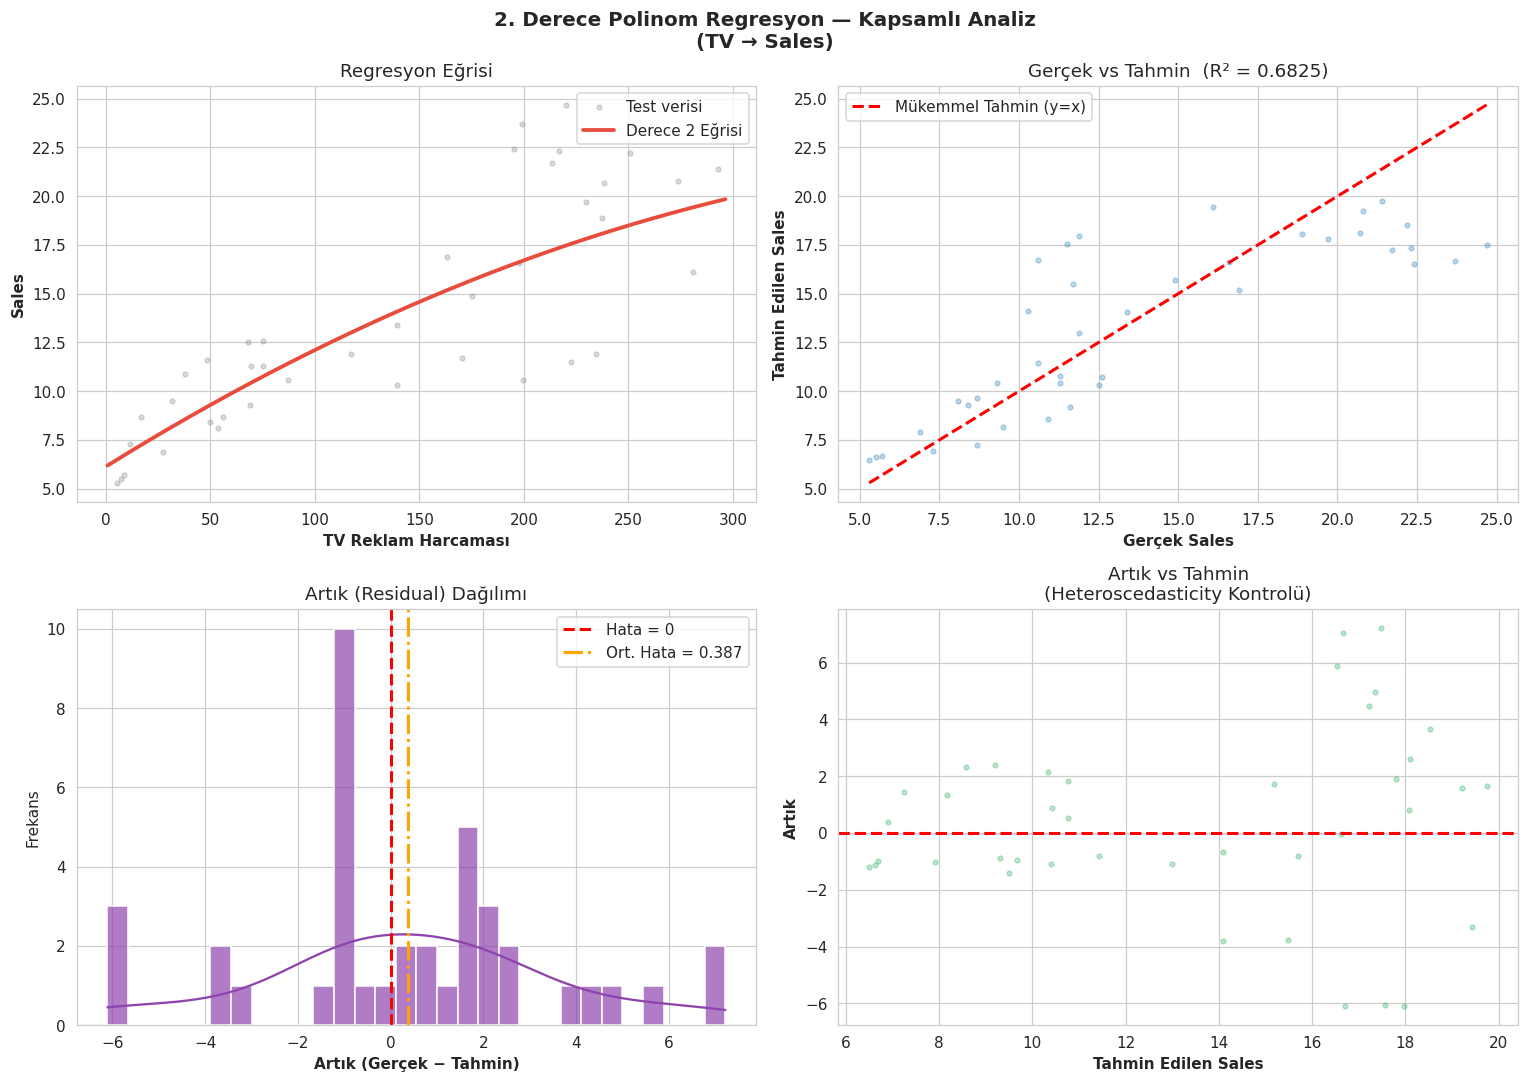

💡 Artık Analizi İçgörüleri:
  • Ortalama artık ≈ 0.3867 (≈0 olması iyi — tarafsız model)
  • Artık std       = 3.1417
  • Artık dağılımı grafik üzerinden değerlendirilebilir.
  • Artık vs Tahmin grafiğinde belirgin bir örüntü olmaması tercih edilir.


In [16]:
#En iyi modeli artık seçiyoruz
best_degree = int(results_df.loc[results_df['Test R²'].idxmax(), 'Derece'])
best_model  = models[best_degree]

y_test_pred  = best_model.predict(X_test)
y_train_pred = best_model.predict(X_train)
residuals    = y_test - y_test_pred   # Artıklar (residuals)

print(f'🏆 Seçilen Model: {best_degree}. Derece Polinom')
print(f'   Train R²   = {r2_score(y_train, y_train_pred):.5f}')
print(f'   Test  R²   = {r2_score(y_test, y_test_pred):.5f}')
print(f'   Test  RMSE = {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}')
print()


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    f'{best_degree}. Derece Polinom Regresyon — Kapsamlı Analiz\n'
    '(TV → Sales)',
    fontsize=13,
    fontweight='bold'
)

# Test verisinden örnek al
sample_size = min(2000, len(X_test))
sample_idx = np.random.choice(
    len(X_test),
    sample_size,
    replace=False
)

# Regresyon eğrisi
axes[0, 0].scatter(
    X_test[sample_idx],
    y_test[sample_idx],
    alpha=0.3,
    s=10,
    color='#7f8c8d',
    label='Test verisi'
)

axes[0, 0].plot(
    X_line,
    best_model.predict(X_line),
    color='#e74c3c',
    linewidth=2.5,
    label=f'Derece {best_degree} Eğrisi'
)

axes[0, 0].set_xlabel('TV Reklam Harcaması', fontweight='bold')
axes[0, 0].set_ylabel('Sales', fontweight='bold')
axes[0, 0].set_title('Regresyon Eğrisi')
axes[0, 0].legend()


#Gerçek vs Tahmin
axes[0, 1].scatter(
    y_test[sample_idx],
    y_test_pred[sample_idx],
    alpha=0.3,
    s=10,
    color='#2980b9'
)

# Mükemmel tahmin çizgisi (y = x)
lims = [
    min(y_test.min(), y_test_pred.min()),
    max(y_test.max(), y_test_pred.max())
]

axes[0, 1].plot(
    lims,
    lims,
    'r--',
    linewidth=2,
    label='Mükemmel Tahmin (y=x)'
)

axes[0, 1].set_xlabel('Gerçek Sales', fontweight='bold')
axes[0, 1].set_ylabel('Tahmin Edilen Sales', fontweight='bold')
axes[0, 1].set_title(
    f'Gerçek vs Tahmin  '
    f'(R² = {r2_score(y_test, y_test_pred):.4f})'
)
axes[0, 1].legend()


#Artık (Residual) dağılımı
sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color='#8e44ad',
    alpha=0.7,
    ax=axes[1, 0]
)

axes[1, 0].axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Hata = 0'
)

axes[1, 0].axvline(
    residuals.mean(),
    color='orange',
    linestyle='-.',
    linewidth=2,
    label=f'Ort. Hata = {residuals.mean():.3f}'
)

axes[1, 0].set_xlabel(
    'Artık (Gerçek − Tahmin)',
    fontweight='bold'
)
axes[1, 0].set_ylabel('Frekans')
axes[1, 0].set_title('Artık (Residual) Dağılımı')
axes[1, 0].legend()


#Artık vs Tahmin
axes[1, 1].scatter(
    y_test_pred[sample_idx],
    residuals[sample_idx],
    alpha=0.3,
    s=10,
    color='#27ae60'
)

axes[1, 1].axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=2
)

axes[1, 1].set_xlabel(
    'Tahmin Edilen Sales',
    fontweight='bold'
)
axes[1, 1].set_ylabel(
    'Artık',
    fontweight='bold'
)
axes[1, 1].set_title(
    'Artık vs Tahmin\n'
    '(Heteroscedasticity Kontrolü)'
)

plt.tight_layout()
plt.show()

print('💡 Artık Analizi İçgörüleri:')
print(
    f'  • Ortalama artık ≈ {residuals.mean():.4f} '
    f'(≈0 olması iyi — tarafsız model)'
)
print(f'  • Artık std       = {residuals.std():.4f}')
print('  • Artık dağılımı grafik üzerinden değerlendirilebilir.')
print('  • Artık vs Tahmin grafiğinde belirgin bir örüntü olmaması tercih edilir.')